# Week 7 Assignment: Data Science Models

Linear regression, logistic regression, and decision tree practice.

## Learning Goals
By the end of this assignment, students should be able to:

1. Explain the difference between regression and classification.
2. Train a linear regression model.
3. Train a logistic regression model.
4. Train a decision tree model.
5. Evaluate model performance using common metrics.

## Submission Instructions
This completed notebook includes working code, outputs, and written answers. Run all cells from top to bottom before submitting or reviewing.

In [15]:
# COMPLETED ANSWER VERSION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.datasets import load_diabetes, load_breast_cancer

print("Libraries imported successfully.")

Libraries imported successfully.


## Part 1: Linear Regression

We will use the diabetes dataset to predict a continuous target.

In [16]:
# Load the diabetes dataset with as_frame=True.
diabetes = load_diabetes(as_frame=True)

# Create X and y.
X = diabetes.data
y = diabetes.target

# Display the first 5 rows of X.
print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)
X.head()

Feature data shape: (442, 10)
Target data shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [17]:
# Split X and y into training and testing data.
# test_size=0.2 means 20% of the data is used for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 353
Testing rows: 89


In [18]:
# Create and train a LinearRegression model.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


In [19]:
# Make predictions on the test set.
y_pred_linear = linear_model.predict(X_test)

# Show the first 10 predicted values.
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": np.round(y_pred_linear[:10], 2)
})

,Actual,Predicted
0,219.0,139.55
1,70.0,179.52
2,202.0,134.04
3,230.0,291.42
4,111.0,123.79
5,84.0,92.17
6,242.0,258.23
7,272.0,181.34
8,94.0,90.22
9,96.0,108.63


In [20]:
# Calculate and print regression metrics.
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Evaluation")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R-squared:", round(r2, 3))

Linear Regression Evaluation
MAE: 42.79
RMSE: 53.85
R-squared: 0.453


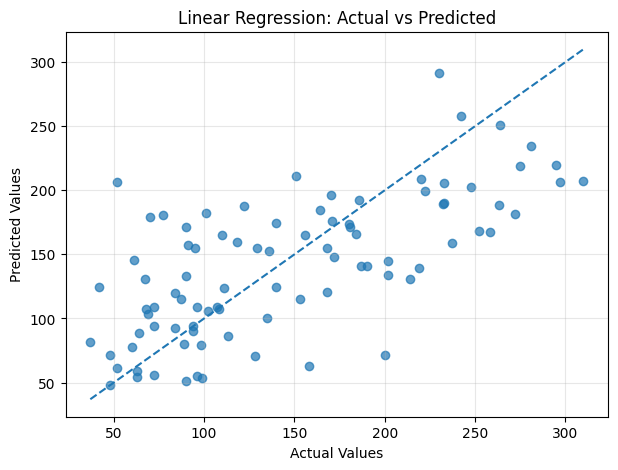

In [21]:
# Create a scatter plot of actual vs predicted values.
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_linear, alpha=0.7)

# Add a diagonal reference line.
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()

## Part 2: Logistic Regression

We will use the breast cancer dataset to predict a binary class.

In [22]:
# Load the breast cancer dataset with as_frame=True.
cancer = load_breast_cancer(as_frame=True)

# Create X and y.
X_class = cancer.data
y_class = cancer.target

# Split into train/test sets.
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Classification feature data shape:", X_class.shape)
print("Class names:", cancer.target_names)
X_class.head()

Classification feature data shape: (569, 30)
Class names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [23]:
# Create and train a LogisticRegression model.
# max_iter is increased so the algorithm has enough iterations to converge.
logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X_train_class, y_train_class)

print("Logistic regression model trained successfully.")

Logistic regression model trained successfully.


In [24]:
# Make predictions and print accuracy, confusion matrix, and classification report.
y_pred_logistic = logistic_model.predict(X_test_class)

logistic_accuracy = accuracy_score(y_test_class, y_pred_logistic)
logistic_cm = confusion_matrix(y_test_class, y_pred_logistic)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 3))
print("\nConfusion Matrix:")
print(logistic_cm)
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_logistic, target_names=cancer.target_names))

Logistic Regression Accuracy: 0.965

Confusion Matrix:
[[39  3]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Part 3: Decision Tree Classifier

In [25]:
# Create and train a DecisionTreeClassifier.
# max_depth=3 keeps the tree small enough to interpret.
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_class, y_train_class)

print("Decision tree model trained successfully.")

Decision tree model trained successfully.


Decision Tree Accuracy: 0.939

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



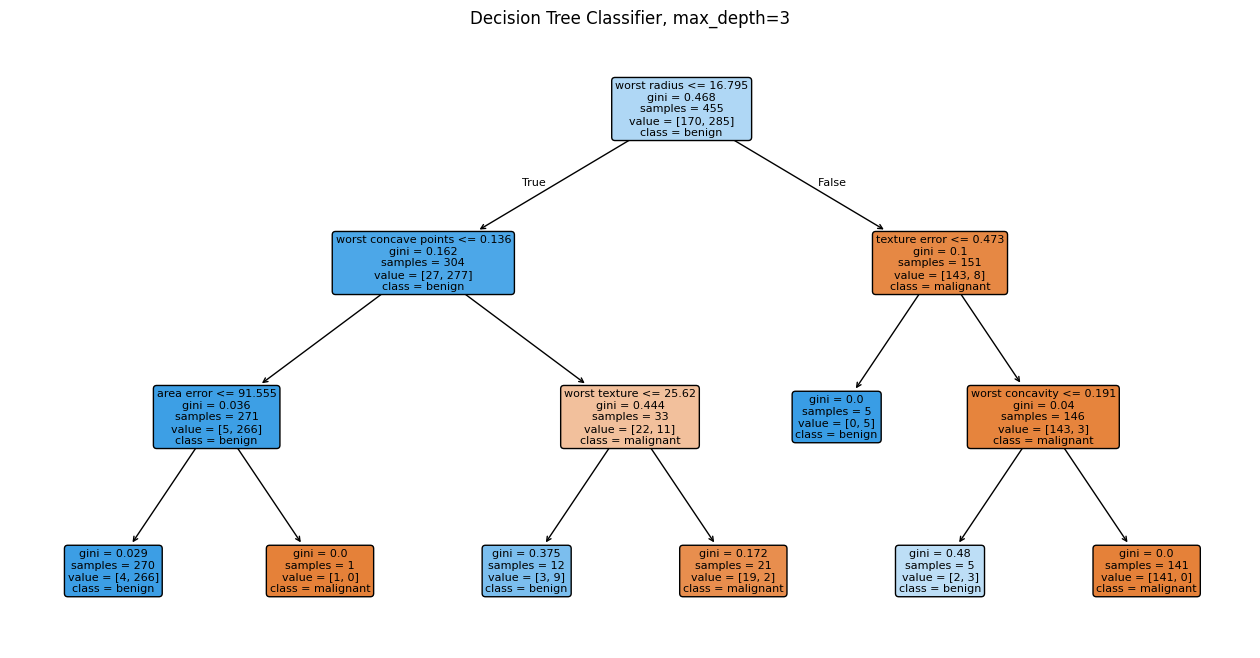

In [26]:
# Evaluate the decision tree using accuracy and classification_report.
y_pred_tree = tree_model.predict(X_test_class)

tree_accuracy = accuracy_score(y_test_class, y_pred_tree)

print("Decision Tree Accuracy:", round(tree_accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_tree, target_names=cancer.target_names))

plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Classifier, max_depth=3")
plt.show()

## Part 4: Compare Models

In [27]:
# Compare logistic regression and decision tree.
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy]
})

comparison["Accuracy"] = comparison["Accuracy"].round(3)
display(comparison)

if logistic_accuracy > tree_accuracy:
    better_model = "Logistic Regression"
elif tree_accuracy > logistic_accuracy:
    better_model = "Decision Tree"
else:
    better_model = "Both models performed equally"

if better_model == "Both models performed equally":
    print("Answer: Both models performed equally on this train/test split.")
else:
    print(f"Answer: {better_model} performed better on this train/test split.")
print("Explanation: Accuracy is the main comparison metric here because this is a binary classification task.")

,Model,Accuracy
0,Logistic Regression,0.965
1,Decision Tree,0.939


Answer: Logistic Regression performed better on this train/test split.
Explanation: Accuracy is the main comparison metric here because this is a binary classification task.


## Challenge Practice

,max_depth,accuracy
0,1,0.921
1,2,0.895
2,4,0.939
3,6,0.912


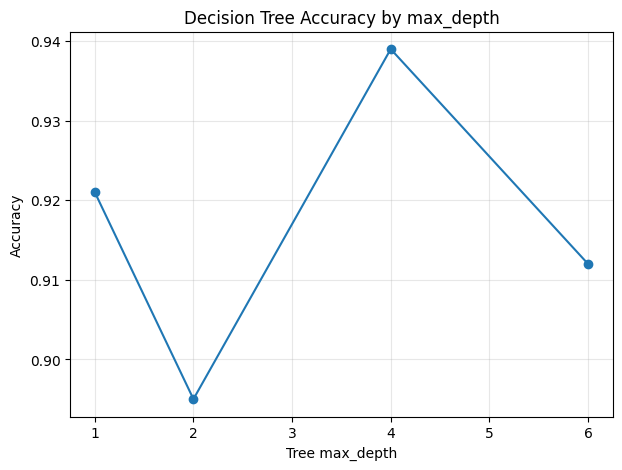

Answer: As max_depth changes, the tree becomes more or less complex.
A very small depth may underfit. A larger depth may improve accuracy, but if it becomes too large it can overfit the training data.


In [28]:
# Change max_depth to 1, 2, 4, and 6.
# Print the accuracy for each tree.
depth_results = []

for depth in [1, 2, 4, 6]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_class, y_train_class)
    predictions = model.predict(X_test_class)
    acc = accuracy_score(y_test_class, predictions)
    depth_results.append({"max_depth": depth, "accuracy": acc})

results_df = pd.DataFrame(depth_results)
results_df["accuracy"] = results_df["accuracy"].round(3)
display(results_df)

plt.figure(figsize=(7, 5))
plt.plot(results_df["max_depth"], results_df["accuracy"], marker="o")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy by max_depth")
plt.grid(True, alpha=0.3)
plt.show()

print("Answer: As max_depth changes, the tree becomes more or less complex.")
print("A very small depth may underfit. A larger depth may improve accuracy, but if it becomes too large it can overfit the training data.")